In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import pandas as pd
import sklearn

In [ ]:
def predict_(x, theta):
    """Computes the vector of prediction y_hat from two non-empty numpy.ndarray.
    Args:
    x: has to be an numpy.ndarray, a one-dimensional array of size m.
    theta: has to be an numpy.ndarray, a one-dimensional array of size 2.
    Returns:
    y_hat as a numpy.ndarray, a one-dimensional array of size m.
    None if x or theta are empty numpy.ndarray.
    None if x or theta dimensions are not appropriate.
    Raises:
    This function should not raise any Exception.
    """
    if x.ndim != 1 or theta.ndim != 1:
        return None
    if theta.shape[0] != 2:
        return None
    m = x.shape[0]
    X = np.column_stack([np.ones(m), x])
    X = X.reshape(m, 2)
    y_hat = X @ theta

    return y_hat


def plot(x, y, theta):
    """Plot the data and prediction line from three non-empty numpy.array.
    Args:
    x: has to be an numpy.array, a one-dimensional array of size m.
    y: has to be an numpy.array, a one-dimensional array of size m.
    theta: has to be an numpy.array, a two-dimensional array of shape 2 * 1.
    Returns:
    Nothing.
    Raises:
    This function should not raise any Exception.
    """
    if x.ndim != 1 or y.ndim != 1 or theta.shape != (2, 1):
        return
    y_hat = predict_(x, theta)
    fig = plt.figure()
    plt.plot(x, y, marker="o")
    plt.plot(x, y_hat, color="orange")
    plt.show()

In [3]:
x = np.arange(1, 6)
theta1 = np.array([5, 0])
theta2 = np.array([0, 1])
theta3 = np.array([5, 3])
theta4 = np.array([-3, 1])
print(predict_(x, theta1))
print(predict_(x, theta2))
print(predict_(x, theta3))
print(predict_(x, theta4))

[5. 5. 5. 5. 5.]
[1. 2. 3. 4. 5.]
[ 8. 11. 14. 17. 20.]
[-2. -1.  0.  1.  2.]


In [4]:
theta1 = np.array([[5], [0]])
theta2 = np.array([[0], [1]])
theta3 = np.array([[5], [3]])
theta4 = np.array([[-3], [1]])
print(predict_(x, theta1))
print(predict_(x, theta2))
print(predict_(x, theta3))
print(predict_(x, theta4))

[[5.]
 [5.]
 [5.]
 [5.]
 [5.]]
[[1.]
 [2.]
 [3.]
 [4.]
 [5.]]
[[ 8.]
 [11.]
 [14.]
 [17.]
 [20.]]
[[-2.]
 [-1.]
 [ 0.]
 [ 1.]
 [ 2.]]


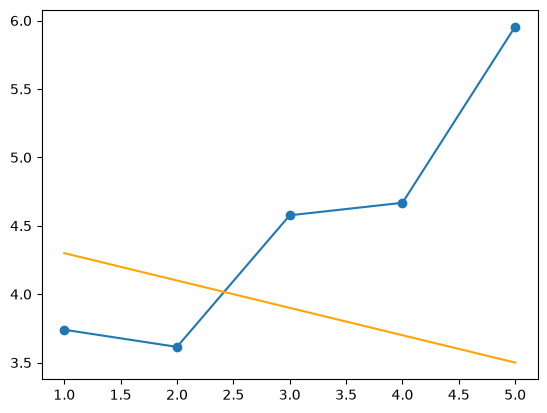

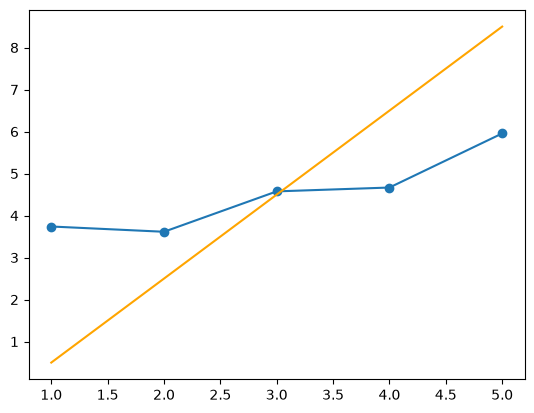

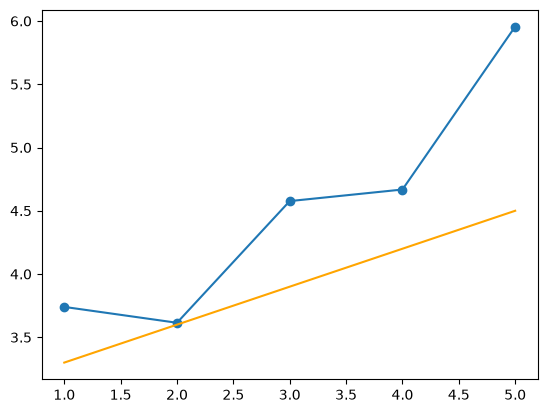

In [5]:
x = np.arange(1, 6)
y = np.array([3.74013816, 3.61473236, 4.57655287, 4.66793434, 5.95585554])
theta1 = np.array([[4.5], [-0.2]])
plot(x, y, theta1)

theta2 = np.array([[-1.5], [2]])
plot(x, y, theta2)

theta3 = np.array([[3], [0.3]])
plot(x, y, theta3)

In [ ]:
def loss_elem_(y, y_hat):
    """
    Description:
    Calculates all the elements (y_pred - y)^2 of the loss function.
    Args:
    y: has to be an numpy.array, a two-dimensional array of shape m * 1.
    y_hat: has to be an numpy.array, a two-dimensional array of shape m * 1.
    Returns:
    J_elem: numpy.array, a array of dimension (number of the training examples, 1).
    None if there is a dimension matching problem.
    None if any argument is not of the expected type.
    Raises:
    This function should not raise any Exception.
    """
    if y.ndim != 2 or y_hat.ndim != 2:
        return None
    if y.shape[1] != 1 or y_hat.shape[1] != 1:
        return None

    J_elem = (y_hat - y) ** 2
    return J_elem


def loss_simple(y, y_hat):
    """
    Description:
    Calculates the value of loss function.
    Args:
    y: has to be an numpy.array, a two-dimensional array of shape m * 1.
    y_hat: has to be an numpy.array, a two-dimensional array of shape m * 1.
    Returns:
    J_value : has to be a float.
    None if there is a dimension matching problem.
    None if any argument is not of the expected type.
    Raises:
    This function should not raise any Exception.
    """
    if not isinstance(y, np.ndarray) or not isinstance(y_hat, np.ndarray):
        return None
    if y.ndim != 2 or y_hat.ndim != 2:
        return None
    if y.shape[1] != 1 or y_hat.shape[1] != 1:
        return None

    m = y.shape[0]
    J_value = 0
    for i in range(m):
        J_value += (y_hat[i][0] - y[i][0]) ** 2
    J_value /= 2 * m
    return J_value

In [7]:
x1 = np.array([[0.0], [1.0], [2.0], [3.0], [4.0]])
theta1 = np.array([[2.0], [4.0]])
y_hat1 = predict_(x1, theta1)
y1 = np.array([[2.0], [7.0], [12.0], [17.0], [22.0]])
print(loss_elem_(y1, y_hat1))
print(loss_simple(y1, y_hat1))
x2 = np.array([0, 15, -9, 7, 12, 3, -21]).reshape(-1, 1)
theta2 = np.array(np.array([[0.0], [1.0]]))
y_hat2 = predict_(x2, theta2)
y2 = np.array([2, 14, -13, 5, 12, 4, -19]).reshape(-1, 1)
print(loss_simple(y2, y_hat2))
print(loss_simple(y2, y2))

[[ 0.]
 [ 1.]
 [ 4.]
 [ 9.]
 [16.]]
3.0
2.142857142857143
0.0


In [ ]:
def loss_(y, y_hat):
    """
    Description:
    Calculates the value of loss function.
    Args:
    y: has to be an numpy.array, a two-dimensional array of shape m * 1.
    y_hat: has to be an numpy.array, a two-dimensional array of shape m * 1.
    Returns:
    J_value : has to be a float.
    None if there is a dimension matching problem.
    """
    if not isinstance(y, np.ndarray) or not isinstance(y_hat, np.ndarray):
        return None
    if y.ndim != 2 or y_hat.ndim != 2:
        return None
    if y.shape[1] != 1 or y_hat.shape[1] != 1:
        return None

    m = y.shape[0]
    return (y_hat - y) @ (y_hat - y) / (2 * m)

In [9]:
X = np.array([0, 15, -9, 7, 12, 3, -21])
Y = np.array([2, 14, -13, 5, 12, 4, -19])
print(loss_(X, Y))

print(loss_(X, X))

2.142857142857143
0.0


In [ ]:
def plot_with_loss(x, y, theta):
    """Plot the data and prediction line from three non-empty numpy.ndarray.
    Args:
    x: has to be an numpy.ndarray, one-dimensional array of size m.
    y: has to be an numpy.ndarray, one-dimensional array of size m.
    theta: has to be an numpy.ndarray, one-dimensional array of size 2.
    Returns:
    Nothing.
    Raises:
    This function should not raise any Exception.
    """
    if (
        not isinstance(x, np.ndarray)
        or not isinstance(y, np.ndarray)
        or not isinstance(theta, np.ndarray)
    ):
        return None
    if x.ndim != 1 or y.ndim != 1 or theta.shape != (2, 1):
        return None

    m = x.shape[0]
    print(m)

    y_hat = predict_(x, theta)
    fig = plt.figure()
    plt.plot(x, y, marker="o")
    plt.plot(x, y_hat, color="orange")
    for i in range(m):
        plt.plot([x[i], x[i]], [y[i], y_hat[i]], linestyle="dashed", color="red")
    plt.show()

5


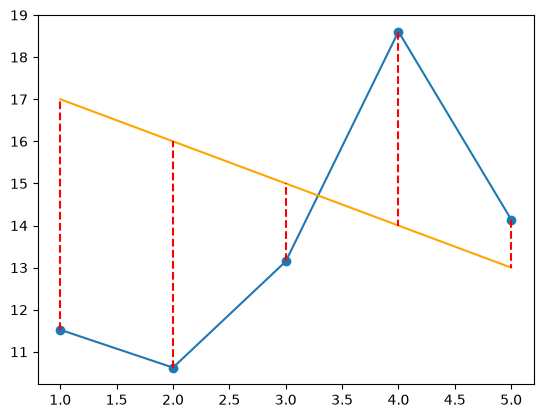

5


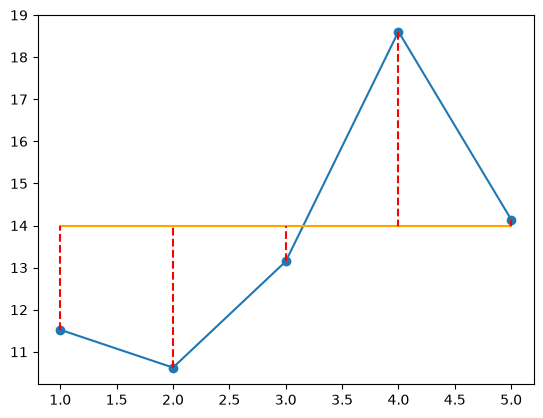

5


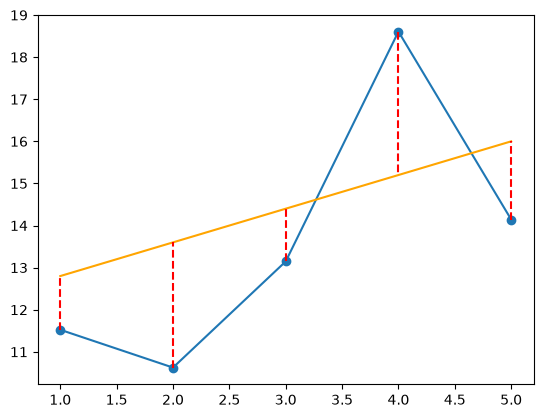

In [11]:
x = np.arange(1, 6)
y = np.array([11.52434424, 10.62589482, 13.14755699, 18.60682298, 14.14329568])
theta1 = np.array([18, -1])
plot_with_loss(x, y, theta1)

theta2 = np.array([14, 0])
plot_with_loss(x, y, theta2)


theta3 = np.array([12, 0.8])
plot_with_loss(x, y, theta3)

In [ ]:
def mse_(y, y_hat):
    """
    Description:
    Calculate the MSE between the predicted output and the real output.
    Args:
    y: has to be a numpy.array, a two-dimensional array of shape m * 1.
    y_hat: has to be a numpy.array, a two-dimensional vector of shape m * 1.
    Returns:
    mse: has to be a float.
    None if there is a matching dimension problem.
    Raises:
    This function should not raise any Exceptions.
    """
    if not isinstance(y, np.ndarray) or not isinstance(y_hat, np.ndarray):
        return None
    if y.ndim != 2 or y_hat.ndim != 2:
        return None
    if y.shape[1] != 1 or y_hat.shape[1] != 1:
        return None

    m = y.shape[0]
    mse = np.sum((y_hat - y) ** 2) / m
    return mse


def rmse_(y, y_hat):
    """
    Description:
    Calculate the RMSE between the predicted output and the real output.
    Args:
    y: has to be a numpy.array, a two-dimensional array of shape m * 1.
    y_hat: has to be a numpy.array, a two-dimensional array of shape m * 1.
    Returns:
    rmse: has to be a float.
    None if there is a matching dimension problem.
    Raises:
    This function should not raise any Exceptions.
    """
    if not isinstance(y, np.ndarray) or not isinstance(y_hat, np.ndarray):
        return None
    if y.ndim != 2 or y_hat.ndim != 2:
        return None
    if y.shape[1] != 1 or y_hat.shape[1] != 1:
        return None

    m = y.shape[0]
    rmse = np.sqrt(np.sum((y_hat - y) ** 2) / m)
    return rmse


def mae_(y, y_hat):
    """
    Description:
    Calculate the MAE between the predicted output and the real output.
    Args:
    y: has to be a numpy.array, a two-dimensional array of shape m * 1.
    y_hat: has to be a numpy.array, a two-dimensional array of shape m * 1.
    Returns:
    mae: has to be a float.
    None if there is a matching dimension problem.
    Raises:
    This function should not raise any Exceptions.
    """
    if not isinstance(y, np.ndarray) or not isinstance(y_hat, np.ndarray):
        return None
    if y.ndim != 2 or y_hat.ndim != 2:
        return None
    if y.shape[1] != 1 or y_hat.shape[1] != 1:
        return None

    m = y.shape[0]
    mae = np.sum(np.abs(y_hat - y)) / m
    return mae


def r2score_(y, y_hat):
    """
    Description:
    Calculate the R2score between the predicted output and the output.
    Args:
    y: has to be a numpy.array, a two-dimensional array of shape m * 1.
    y_hat: has to be a numpy.array, a two-dimensional array of shape m * 1.
    Returns:
    r2score: has to be a float.
    None if there is a matching dimension problem.
    Raises:
    This function should not raise any Exceptions.
    """
    if not isinstance(y, np.ndarray) or not isinstance(y_hat, np.ndarray):
        return None
    if y.ndim != 2 or y_hat.ndim != 2:
        return None
    if y.shape[1] != 1 or y_hat.shape[1] != 1:
        return None

    ss_res = np.sum((y_hat - y) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2score = 1 - (ss_res / ss_tot)

    return r2score

In [13]:
from math import sqrt

x = np.array([[0], [15], [-9], [7], [12], [3], [-21]])
y = np.array([[2], [14], [-13], [5], [12], [4], [-19]])

assert np.isclose(mse_(x, y), 4.285714285714286)
assert np.isclose(sklearn.metrics.mean_squared_error(x, y), 4.285714285714286)
assert np.isclose(rmse_(x, y), 2.0701966780270626)
assert np.isclose(sqrt(sklearn.metrics.mean_squared_error(x, y)), 2.0701966780270626)
print(mae_(x, y))
assert np.isclose(mae_(x, y), 1.7142857142857142)
assert np.isclose(sklearn.metrics.mean_absolute_error(x, y), 1.7142857142857142)
assert np.isclose(r2score_(x, y), 0.9681721733858745, atol=0.0001)
sklearn.metrics.r2_score(x, y)
assert np.isclose(sklearn.metrics.r2_score(x, y), 0.9681721733858745, atol=0.0001)

1.7142857142857142
